In [3]:
# 1) Import Librries
# 2) Imort Dataset
# 3) Data Cleaning
# 4) EDA
# 5) Text Processing
# 6) Model Building
# 7) Evaluation
# 8) Improvement
# 9) Website
# 10) Deploy



## 1)Import Libraries

In [4]:
import numpy as np
import pandas as pd

## 2) Import DataSet

In [5]:
dataset = pd.read_csv("spam.csv", encoding='latin-1')

In [6]:
dataset.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2725,ham,No. But we'll do medical missions to nigeria,NaN,NaN,NaN
1146,ham,Babe ? I lost you ... :-(,NaN,NaN,NaN
5497,spam,"SMS SERVICES. for your inclusive text credits,...",NaN,NaN,NaN
2416,ham,"Could you not read me, my Love ? I answered you",NaN,NaN,NaN
4119,ham,Babe! How goes that day ? What are you up to ?...,NaN,NaN,NaN


In [7]:
dataset.shape

(5572, 5)

## 3) Data Cleaning

In [8]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [9]:
dataset.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [10]:
dataset.sample(5)

,v1,v2
4744,spam,Camera - You are awarded a SiPix Digital Camer...
2391,ham,PICK UR FONE UP NOW U DUMB?
4927,ham,Just hopeing that wasnÛ÷t too pissed up to re...
5495,ham,"Good afternoon, my love ... How goes your day ..."
5105,ham,I wnt to buy a BMW car urgently..its vry urgen...


In [11]:
# Rename the columns
dataset.rename(columns={'v1':'Target', 'v2': 'Text'}, inplace=True)
dataset.sample(1)

,Target,Text
1806,spam,Todays Voda numbers ending 1225 are selected t...


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()
dataset['Target'] = encoder.fit_transform(dataset['Target'])
dataset.sample(5)

,Target,Text
4572,1,\URGENT! This is the 2nd attempt to contact U!...
3993,0,I love to cuddle! I want to hold you in my str...
68,1,"Did you hear about the new \Divorce Barbie\""? ..."
4026,0,"Yes, princess. Are you going to make me moan?"
5155,0,MY NEW YEARS EVE WAS OK. I WENT TO A PARTY WIT...


In [14]:
# Check Missing Values

dataset.isnull().any

<bound method DataFrame.any of       Target   Text
0      False  False
1      False  False
2      False  False
3      False  False
4      False  False
...      ...    ...
5567   False  False
5568   False  False
5569   False  False
5570   False  False
5571   False  False

[5572 rows x 2 columns]>

In [15]:
dataset.isnull().sum()

Target    0
Text      0
dtype: int64

In [16]:
# Check Dublicate values
dataset.duplicated().sum()

np.int64(403)

In [17]:
dataset = dataset.drop_duplicates(keep='first')

In [18]:
dataset.duplicated().sum()

np.int64(0)

In [19]:
dataset.shape

(5169, 2)

## 2) EDA

In [20]:
dataset['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

In [21]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x18928db8590>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37%'),
  Text(0.553363565906573, -0.231924047755212, '12.63%')])

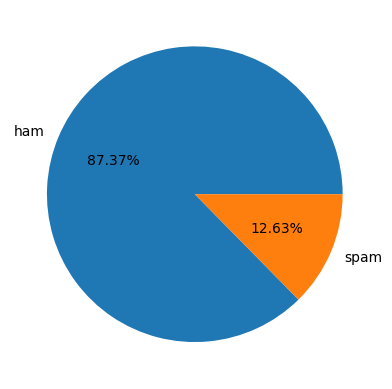

In [22]:
plt.pie(dataset["Target"].value_counts(), labels=['ham', 'spam'], autopct="%0.2f%%")

In [23]:
!pip install nltk

In [24]:
import nltk

In [57]:
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
dataset['data_num'] = dataset["Text"].apply(len)

In [27]:
dataset.head()

,Target,Text,data_num
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
dataset['num_words'] = dataset['Text'].apply(lambda x:len(nltk.word_tokenize(x, preserve_line=True)))

In [29]:
dataset.head()

,Target,Text,data_num,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [30]:
dataset['num_sentence'] = dataset['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [31]:
dataset.head()

,Target,Text,data_num,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [32]:
dataset[['data_num','num_words', 'num_sentence']].describe()

,data_num,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,17.864964,1.965564
std,58.236293,12.776749,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,14.000000,1.000000
75%,117.000000,25.000000,2.000000
max,910.000000,215.000000,38.000000


In [33]:
dataset['Target'] == 0

0        True
1        True
2       False
3        True
4        True
        ...  
5567    False
5568     True
5569     True
5570     True
5571     True
Name: Target, Length: 5169, dtype: bool

In [34]:
dataset[dataset['Target'] == 0][['data_num','num_words', 'num_sentence']].describe()

,data_num,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,16.618468,1.820195
std,56.358207,12.962931,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,21.000000,2.000000
max,910.000000,215.000000,38.000000


In [35]:
dataset[dataset['Target'] == 1][['data_num','num_words', 'num_sentence']].describe()

,data_num,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,26.485452,2.970904
std,30.137753,6.717242,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,24.000000,2.000000
50%,149.000000,28.000000,3.000000
75%,157.000000,31.000000,4.000000
max,224.000000,46.000000,9.000000


In [36]:
!pip install seaborn

In [37]:
import seaborn as sns

<Axes: xlabel='data_num', ylabel='Count'>

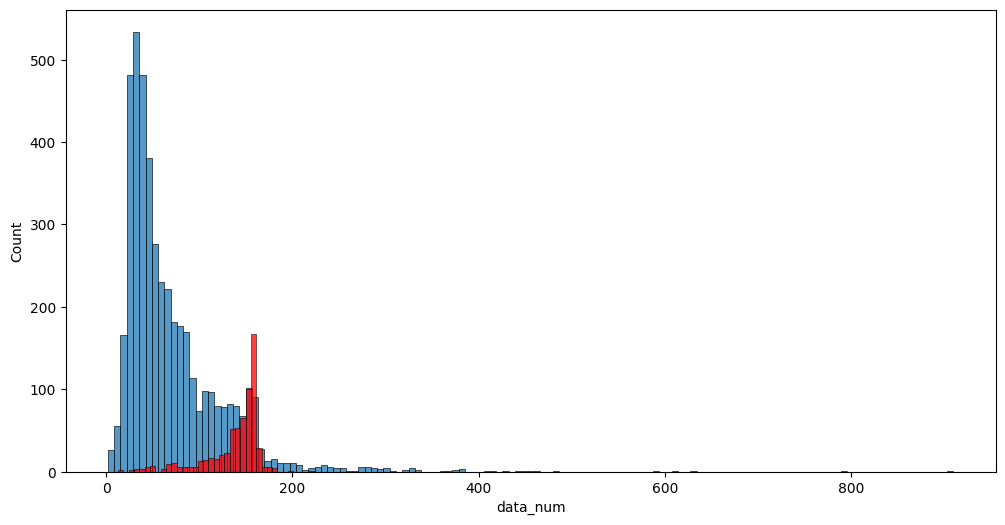

In [38]:
plt.figure(figsize=(12, 6))
sns.histplot(dataset[dataset['Target'] == 0]['data_num'])
sns.histplot(dataset[dataset['Target'] == 1]['data_num'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

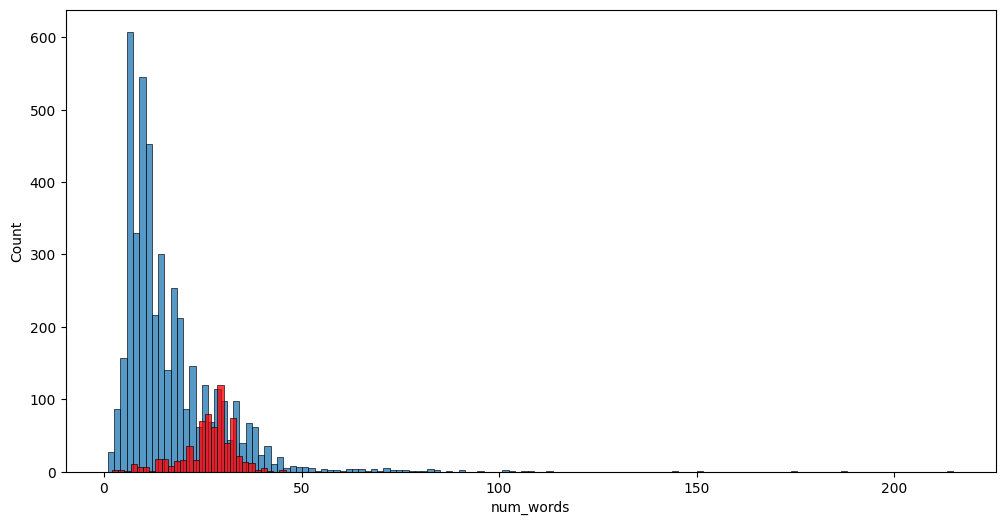

In [39]:
plt.figure(figsize=(12, 6))
sns.histplot(dataset[dataset['Target'] == 0]['num_words'])
sns.histplot(dataset[dataset['Target'] == 1]['num_words'], color='red')

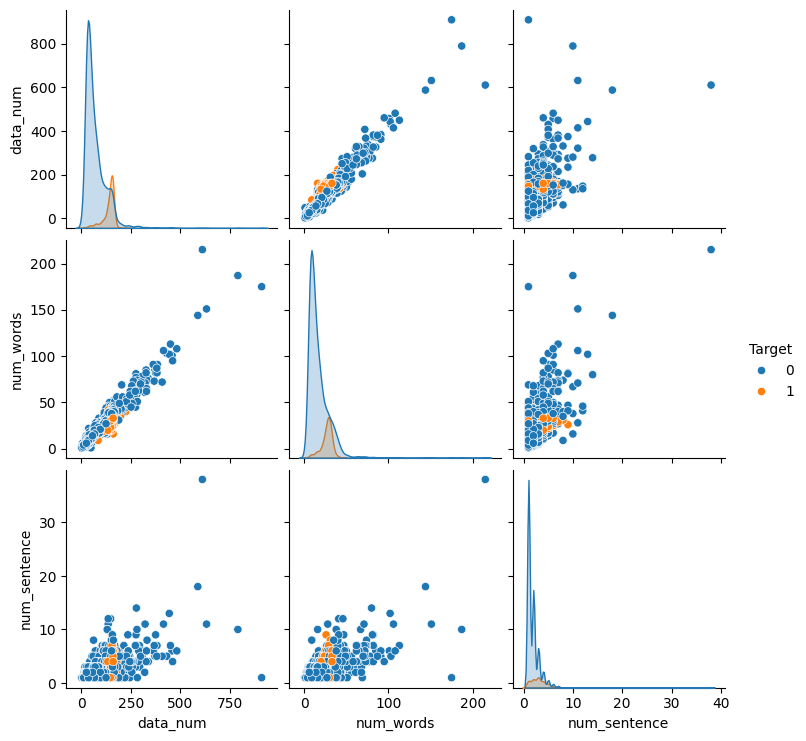

In [40]:
sns.pairplot(dataset, hue="Target")

<Axes: >

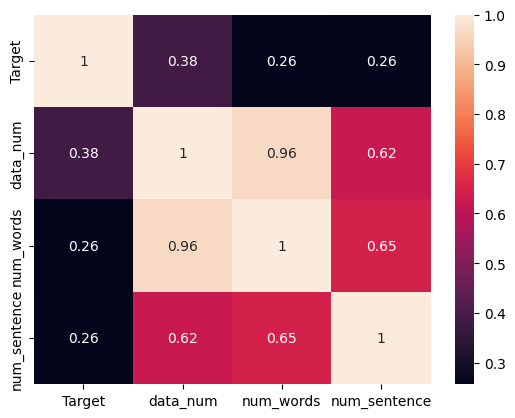

In [41]:
sns.heatmap(dataset.corr(numeric_only=True), annot = True)

## 3) Data Prerocessing

In [69]:
from nltk.corpus import stopwords
import string

def transform_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Tokenize
    text = nltk.word_tokenize(text)
    
    # 3. Remove non-alphanumeric
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # 4. Remove stopwords & punctuation
    text = y
    y = []
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    # Stem word
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
                
    
    return " ".join(y)

In [74]:
# Special character removed
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [165]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [71]:
dataset['Text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [66]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [78]:
dataset['transform_text'] = dataset['Text'].apply(transform_text)

In [79]:
dataset.head()

,Target,Text,data_num,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [97]:
from wordcloud import WordCloud
wc = WordCloud(width=800,  height=800, min_font_size=10, background_color='white')

In [98]:
spam_wc = wc.generate(dataset[dataset['Target'] == 1]['transform_text'].str.cat(sep=" "))

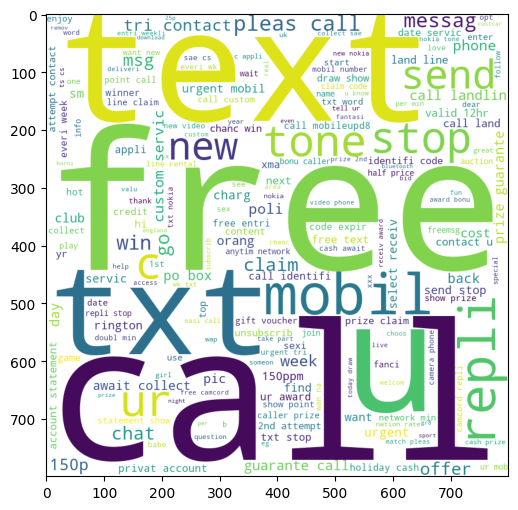

In [99]:
plt.figure(figsize= (12, 6))
plt.imshow(spam_wc)

In [101]:
ham_wc = wc.generate(dataset[dataset['Target'] == 0]['transform_text'].str.cat(sep=" "))

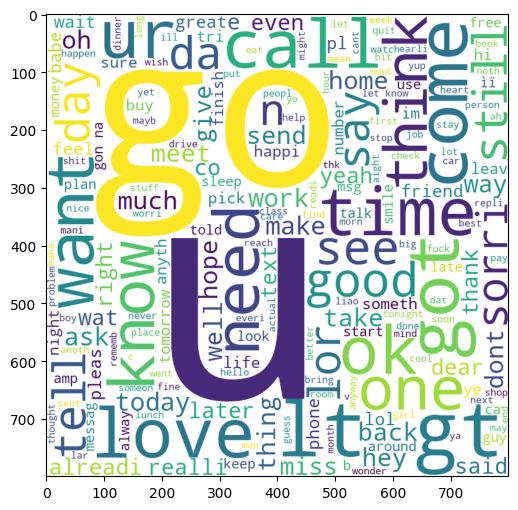

In [104]:
plt.figure(figsize=(12, 6))
plt.imshow(ham_wc)    

In [123]:
spam_corpus = []
for msg in dataset[dataset['Target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [124]:
len(spam_corpus)

9939

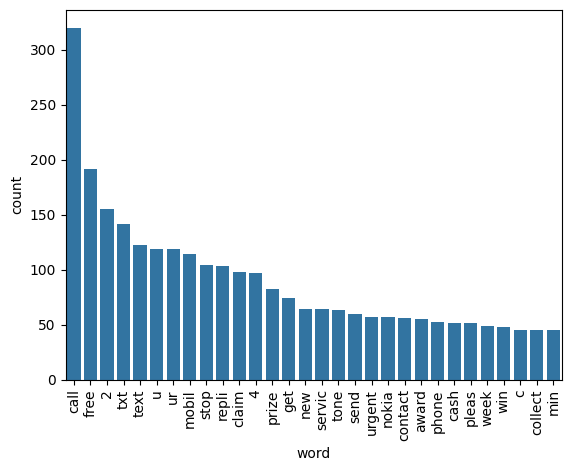

In [125]:
from collections import Counter
df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df)
plt.xticks(rotation=90)
plt.show()

In [126]:
ham_corpus = []
for msg in dataset[dataset['Target'] == 0]['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [127]:
len(ham_corpus)

35404

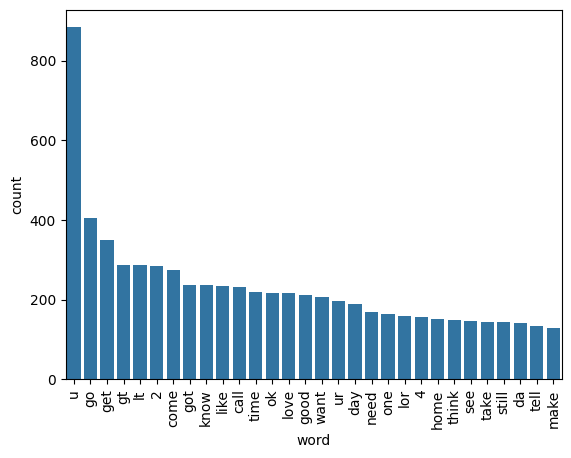

In [128]:
from collections import Counter
df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df)
plt.xticks(rotation=90)
plt.show()

## 4) Model Building

In [225]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 3000)

In [226]:
X = tfidf.fit_transform(dataset['transform_text']).toarray()

In [227]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)

In [228]:
X.shape

(5169, 3000)

In [229]:
Y = dataset['Target'].values

In [230]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [231]:
from sklearn.model_selection import train_test_split

In [232]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [233]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB 
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [234]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [235]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [236]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [237]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [238]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('mdel.pkl', 'wb'))